### Ejemplo de SVM Multiclase Tradicional del tipo categorias vs todo.

Un conjunto de datos de la misma categoría vs todos los demas.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist['data'], mnist['target'].astype(int)

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# --- Create training data: fewer samples for fast training ---
samples_per_class = 300
X_small = []
y_small = []

for digit in range(10):
    idx = np.where(y == digit)[0][:samples_per_class]
    X_small.append(X[idx])
    y_small.append(y[idx])

X_small = np.vstack(X_small)
y_small = np.hstack(y_small)

# --- Create test data ---
test_samples_per_class = 100
X_test = []
y_test = []

for digit in range(10):
    idx = np.where(y == digit)[0][samples_per_class:samples_per_class + test_samples_per_class]
    X_test.append(X[idx])
    y_test.append(y[idx])

X_test = np.vstack(X_test)
y_test = np.hstack(y_test)
X_test = scaler.transform(X_test)

# --- Train one-vs-all SVMs (10 classifiers) ---
classifiers = {}
for digit in range(10):
    binary_labels = (y_small == digit).astype(int)
    clf = SVC(kernel='linear', probability=True)
    clf.fit(X_small, binary_labels)
    classifiers[digit] = clf

In [3]:
print("\nAccuracy of each one-vs-all SVM on the test data:")

for digit in range(10):
    binary_labels = (y_test == digit).astype(int)
    y_pred = classifiers[digit].predict(X_test)
    acc = accuracy_score(binary_labels, y_pred)
    print(f"SVM for digit {digit}: Test Accuracy = {acc * 100:.2f}%")


Accuracy of each one-vs-all SVM on the test data:
SVM for digit 0: Test Accuracy = 90.00%
SVM for digit 1: Test Accuracy = 89.80%
SVM for digit 2: Test Accuracy = 90.00%
SVM for digit 3: Test Accuracy = 90.00%
SVM for digit 4: Test Accuracy = 90.00%
SVM for digit 5: Test Accuracy = 90.60%
SVM for digit 6: Test Accuracy = 90.00%
SVM for digit 7: Test Accuracy = 89.90%
SVM for digit 8: Test Accuracy = 90.00%
SVM for digit 9: Test Accuracy = 90.00%



Predictions for digit 3 test image:


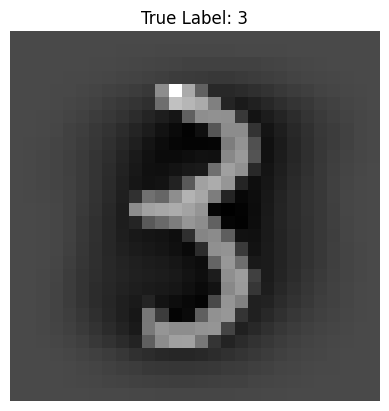

Classifier for 0 predicts: 0
Classifier for 1 predicts: 0
Classifier for 2 predicts: 0
Classifier for 3 predicts: 1
Classifier for 4 predicts: 0
Classifier for 5 predicts: 0
Classifier for 6 predicts: 0
Classifier for 7 predicts: 0
Classifier for 8 predicts: 0
Classifier for 9 predicts: 0

Predictions for one image from each other digit (≠ target):


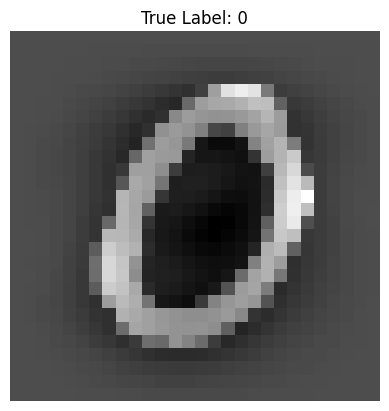

Classifier for 0 predicts: 1
Classifier for 1 predicts: 0
Classifier for 2 predicts: 0
Classifier for 3 predicts: 0
Classifier for 4 predicts: 0
Classifier for 5 predicts: 0
Classifier for 6 predicts: 0
Classifier for 7 predicts: 0
Classifier for 8 predicts: 0
Classifier for 9 predicts: 0
------------------------------


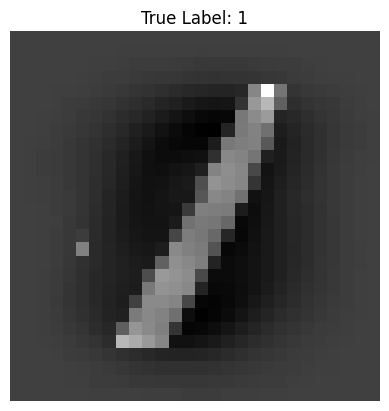

Classifier for 0 predicts: 0
Classifier for 1 predicts: 1
Classifier for 2 predicts: 0
Classifier for 3 predicts: 0
Classifier for 4 predicts: 0
Classifier for 5 predicts: 0
Classifier for 6 predicts: 0
Classifier for 7 predicts: 0
Classifier for 8 predicts: 0
Classifier for 9 predicts: 0
------------------------------


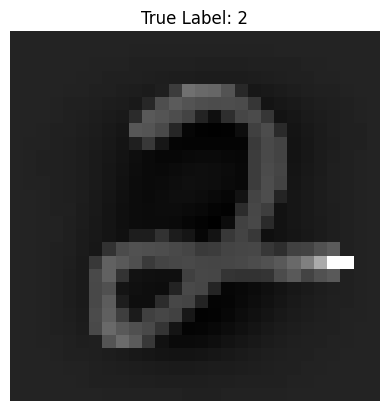

Classifier for 0 predicts: 0
Classifier for 1 predicts: 0
Classifier for 2 predicts: 1
Classifier for 3 predicts: 0
Classifier for 4 predicts: 0
Classifier for 5 predicts: 0
Classifier for 6 predicts: 0
Classifier for 7 predicts: 0
Classifier for 8 predicts: 0
Classifier for 9 predicts: 0
------------------------------


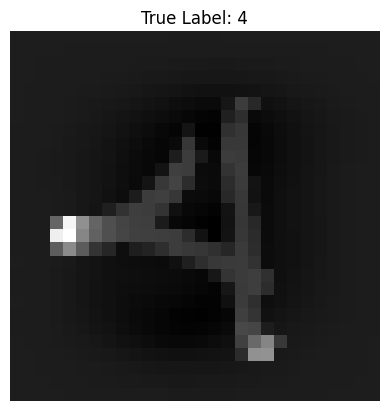

Classifier for 0 predicts: 0
Classifier for 1 predicts: 0
Classifier for 2 predicts: 0
Classifier for 3 predicts: 0
Classifier for 4 predicts: 1
Classifier for 5 predicts: 0
Classifier for 6 predicts: 0
Classifier for 7 predicts: 0
Classifier for 8 predicts: 0
Classifier for 9 predicts: 0
------------------------------


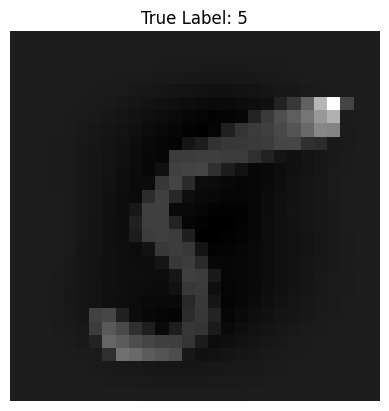

Classifier for 0 predicts: 0
Classifier for 1 predicts: 0
Classifier for 2 predicts: 0
Classifier for 3 predicts: 0
Classifier for 4 predicts: 0
Classifier for 5 predicts: 1
Classifier for 6 predicts: 0
Classifier for 7 predicts: 0
Classifier for 8 predicts: 0
Classifier for 9 predicts: 0
------------------------------


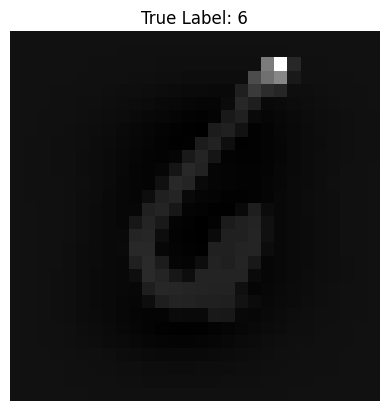

Classifier for 0 predicts: 0
Classifier for 1 predicts: 0
Classifier for 2 predicts: 0
Classifier for 3 predicts: 0
Classifier for 4 predicts: 0
Classifier for 5 predicts: 0
Classifier for 6 predicts: 1
Classifier for 7 predicts: 0
Classifier for 8 predicts: 0
Classifier for 9 predicts: 0
------------------------------


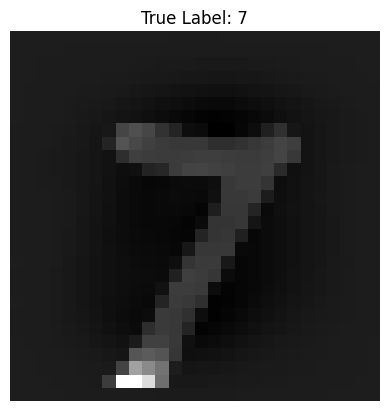

Classifier for 0 predicts: 0
Classifier for 1 predicts: 0
Classifier for 2 predicts: 0
Classifier for 3 predicts: 0
Classifier for 4 predicts: 0
Classifier for 5 predicts: 0
Classifier for 6 predicts: 0
Classifier for 7 predicts: 1
Classifier for 8 predicts: 0
Classifier for 9 predicts: 0
------------------------------


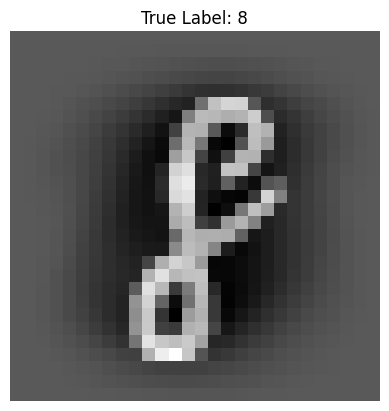

Classifier for 0 predicts: 0
Classifier for 1 predicts: 0
Classifier for 2 predicts: 0
Classifier for 3 predicts: 0
Classifier for 4 predicts: 0
Classifier for 5 predicts: 0
Classifier for 6 predicts: 0
Classifier for 7 predicts: 0
Classifier for 8 predicts: 1
Classifier for 9 predicts: 0
------------------------------


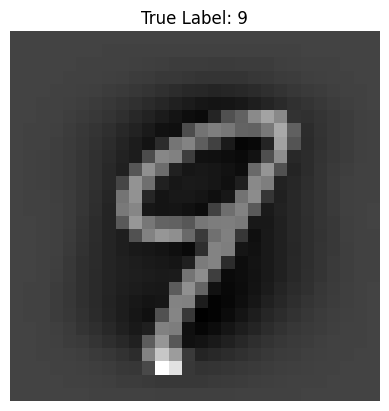

Classifier for 0 predicts: 0
Classifier for 1 predicts: 0
Classifier for 2 predicts: 0
Classifier for 3 predicts: 0
Classifier for 4 predicts: 0
Classifier for 5 predicts: 0
Classifier for 6 predicts: 0
Classifier for 7 predicts: 0
Classifier for 8 predicts: 0
Classifier for 9 predicts: 1
------------------------------


In [4]:
target_digit = 3

# Find a test image of the target digit
target_idx = np.where(y == target_digit)[0][samples_per_class]  # offset = training samples used
x_target = X[target_idx]
y_target = y[target_idx]

print(f"\nPredictions for digit {target_digit} test image:")
plt.imshow(x_target.reshape(28, 28), cmap='gray')
plt.title(f"True Label: {y_target}")
plt.axis('off')
plt.show()

for digit, clf in classifiers.items():
    pred = clf.predict([x_target])[0]
    print(f"Classifier for {digit} predicts: {int(pred)}")

# --- Show predictions for one sample from each other digit ---
print("\nPredictions for one image from each other digit (≠ target):")
for other_digit in range(10):
    if other_digit == target_digit:
        continue
    idx = np.where(y == other_digit)[0][samples_per_class]
    x_other = X[idx]
    y_other = y[idx]

    plt.imshow(x_other.reshape(28, 28), cmap='gray')
    plt.title(f"True Label: {y_other}")
    plt.axis('off')
    plt.show()

    for digit, clf in classifiers.items():
        pred = clf.predict([x_other])[0]
        print(f"Classifier for {digit} predicts: {int(pred)}")
    print("-" * 30)

## Ejemplo de un Exemplar SVM

Es 1 muestra vs todo lo demas

In [11]:
from sklearn import datasets
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar dataset de dígitos (imágenes 8x8)
digits = datasets.load_digits()

# 2. Seleccionar un ejemplar positivo (un solo "8")
positive_idx = np.where(digits.target == 8)[0][0]  # primer "8"
X_exemplar = digits.images[positive_idx].reshape(1, -1)  # 1x64
y_exemplar = [1]  # Etiqueta positiva


In [12]:
# 3. Tomar un conjunto de ejemplos negativos (dígitos que no son 8)
neg_indices = np.where(digits.target != 8)[0]
X_negatives = digits.images[neg_indices]
X_negatives = X_negatives.reshape(X_negatives.shape[0], -1)
y_negatives = np.zeros(X_negatives.shape[0])  # Etiquetas negativas (0)

# 4. Unir positivo y negativos
X_train = np.vstack((X_exemplar, X_negatives))
y_train = np.hstack((y_exemplar, y_negatives))


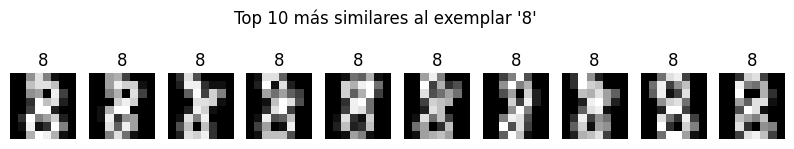

In [13]:
# 5. Entrenar un SVM lineal (nuestro Exemplar SVM)
svm = LinearSVC(class_weight='balanced', max_iter=10000)
svm.fit(X_train, y_train)

# 6. Evaluar sobre todo el conjunto de datos
X_all = digits.images.reshape((digits.images.shape[0], -1))
y_scores = svm.decision_function(X_all)

# 7. Mostrar los 10 dígitos más similares al exemplar
top_indices = np.argsort(y_scores)[-10:]

plt.figure(figsize=(10, 2))
for i, idx in enumerate(top_indices[::-1]):
    plt.subplot(1, 10, i + 1)
    plt.imshow(digits.images[idx], cmap='gray')
    plt.axis('off')
    plt.title(f"{digits.target[idx]}")
plt.suptitle("Top 10 más similares al exemplar '8'")
plt.show()


In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Crear etiquetas reales: 1 si el dígito es 8, 0 si no
y_true = (digits.target == 8).astype(int)

# Predicciones binarizadas: 1 si la puntuación del SVM > 0, 0 si no
y_pred = (y_scores > 0).astype(int)

# Calcular métricas
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nEvaluación del Exemplar SVM para el dígito '8':")
print(f"Precisión: {precision:.2f}")
print(f"Recall (sensibilidad): {recall:.2f}")
print(f"F1-score: {f1:.2f}")



Evaluación del Exemplar SVM para el dígito '8':
Precisión: 1.00
Recall (sensibilidad): 0.02
F1-score: 0.03


Que nos dicen estas métricas,

- Por un lado, siempre que nuestro modelo diga que ese valor es un 8, realmente si es un 8, o sea que no hay valores falsos positivos (precision).
- Respecto al recall, nos queda bajo, indicando que hay muchos valores que si eran 8 y no los clasifico como un 8, esto se puede deber a que, tenemos solo 1 valor 8 del cual aprende nuestro valor.
- el f1 score nos dice que la relacion entre el recall y la precision es dispareja, o sea, el  recall es muy bajo

Una posible solucion es entrenar varios exemplar svm para el mismo número y ver una ponderación de estos. Ya que dependiendo el 8 que le entreguemos es como discriminará los otros números.

### ¿ Qué pasa con el accuracy?, ¿Mejorará o disminuirá respecto al SVM tradicional?

In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy del Exemplar SVM para el dígito '8': {accuracy:.2f}")


Accuracy del Exemplar SVM para el dígito '8': 0.90


### Por qué el accuracy es tan alto?, si sabemos que el recall es bajo o sea que nuestro modelo el 98% de las veces que si era "8" las clasifica como si no fueran un "8".

# Respuesta:

- TP = 3               → Predijo 8 y era 8 (correcto)
- FN = 175             → Era 8 pero no lo predijo como tal
- TN ≈ 1616            → Era no-8 y predijo no-8 (correcto)
- FP = 0               → No hay falsos positivos


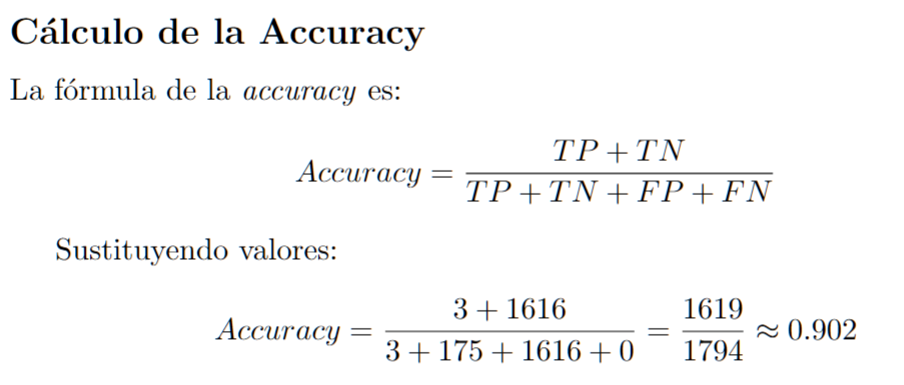